In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from collections.abc import Iterable
from basic_conv1d import bn_drop_lin
import warnings
warnings.filterwarnings('ignore')
from clinical_ts.template_modules import ShapeConfig
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [2]:


class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims)==hparams_input_shape.static_dim_cat and len(hparams_encoder_static.vocab_sizes)==hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList() if hparams_input_shape.static_dim_cat is not None else None
        for v,e in zip(hparams_encoder_static.vocab_sizes,hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v,e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)
        self.input_channels = hparams_input_shape.static_dim + hparams_input_shape.static_dim_cat


    def embed(self, **kwargs):
        static = kwargs["static"] if "static" in kwargs.keys() else None
        static_cat = kwargs["static_cat"] if "static_cat" in kwargs.keys() else None

        res = []
        if(static_cat is not None):
            for i,e in enumerate(self.embeddings):
                res.append(e(static_cat[:,i].long()))
            if(static is not None and static_cat is not None):
                res = torch.cat([torch.cat(res,dim=1),static],dim=1)
            else:
                res = torch.cat(res,dim=1)
        else:
            res = static

        return res

    def forward(self, **kwargs):
        raise NotImplementedError

    def get_output_shape(self):
        raise NotImplementedError

@dataclass
class BasicEncoderStaticConfig(EncoderStaticBaseConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStatic"
    embedding_dims:List[int] = field(default_factory=lambda: []) #list with embedding dimensions
    vocab_sizes:List[int] = field(default_factory=lambda: []) #list with vocab sizes (space-separated)

class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)

        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if(target_dim is not None and lin_ftrs[-1]!=target_dim):
            lin_ftrs.append(target_dim)
        ps = [hparams_encoder_static.dropout] if not isinstance(hparams_encoder_static.dropout, Iterable) else hparams_encoder_static.dropout
        if len(ps)==1:
            ps= [ps[0]/2] * (len(lin_ftrs)-2) + ps
        actns = [nn.ReLU(inplace=True)] * (len(lin_ftrs)-2) + [None]
        layers = []
        for ni,no,p,actn in zip(lin_ftrs[:-1],lin_ftrs[1:],ps,actns):
            layers+=bn_drop_lin(ni,no,hparams_encoder_static.batch_norm,p,actn,layer_norm=False)
        self.layers=nn.Sequential(*layers)

        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        res = self.embed(**kwargs)
        return {"static": self.layers(res)}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class BasicEncoderStaticMLPConfig(BasicEncoderStaticConfig):
    _target_:str = "clinical_ts.tabular.base.BasicEncoderStaticMLP"
    lin_ftrs:List[int] = field(default_factory=lambda: [512]) #list with MLP hidden layer sizes; last entry is the static encoder output dimension in case target_dim is not specified
    dropout:float = 0.5
    batch_norm:bool = True

In [3]:
# ----------------------------------------
# Config (matches YAML)
# ----------------------------------------
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 0.001
WEIGHT_DECAY = 0.001
DROPOUT    = 0.5
LIN_FTRS   = [128, 128, 128]

In [4]:
# ----------------------------------------
# 1. Load data (same as multimodal.py)
# ----------------------------------------
print("Loading data...")
df = pd.read_csv(r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv',
                 low_memory=False)
print(f"shape: {df.shape}")

Loading data...
shape: (129057, 1936)


In [5]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]

# median imputation based on training set
df_train = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
train_nans = [c for c,v in df_train[input_cols].isna().sum().to_dict().items() if v > 0]
for c in train_nans:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

In [6]:
# categorical vs continuous feature split (same as multimodal.py)
unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features = [c for c,v in unique_counts.items() if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cat_features_dim = [unique_counts[c] for c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

print(f"categorical features: {len(cat_features)} dimensions: {cat_features_dim} continuous features: {len(cont_features)}")

categorical features: 7 dimensions: [2, 2, 2, 2, 2, 2, 5] continuous features: 463


In [7]:
# vitals_acuity: convert from 1-based to 0-based indexing
df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x)-1)

# ethnicity → categorical encoding (same as multimodal.py)
lbl_itos_ethnicity = [
    'demographics_ethnicity_asian',
    'demographics_ethnicity_black/african',
    'demographics_ethnicity_hispanic/latino',
    'demographics_ethnicity_other',
    'demographics_ethnicity_white'
]

df["demographics_ethnicity"] = df.apply(
    lambda row: np.where([row[c] for c in lbl_itos_ethnicity])[0][0], axis=1
)
df.drop(lbl_itos_ethnicity, axis=1, inplace=True)

In [8]:
input_cols = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features = [c for c in cat_features if c in df.columns]
cat_features = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

# deterioration labels
lbl_itos_deterioration = ["mortality_1d","icu_24h","cardiac_arrest","vasopressors"]
for c in lbl_itos_deterioration:
    df["deterioration_"+c] = df["deterioration_"+c].replace(-999., np.nan)

In [9]:
target_cols = [
    "deterioration_mortality_1d",
    "deterioration_icu_24h",
    "deterioration_icu_24h",
    "deterioration_vasopressors"
]

In [10]:
# 3. Train / Validation / Test split
# ----------------------------------------
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)
# only first ECG per hospital stay for validation/test
val_df   = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df  = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

Train: 116433, Validation: 5824, Test: 6080


In [11]:
# 4. Dataset
# ----------------------------------------
class TabularDataset(Dataset):
    def __init__(self, df, cont_features, cat_features, lbl_cols):
        self.cont = torch.tensor(df[cont_features].values, dtype=torch.float32)
        self.cat  = torch.tensor(df[cat_features].values, dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)

    def __len__(self):
        return len(self.cont)

    def __getitem__(self, idx):
        return self.cont[idx], self.cat[idx], self.labels[idx]

train_ds = TabularDataset(train_df, cont_features, cat_features, lbl_itos_deterioration)
val_ds   = TabularDataset(val_df,   cont_features, cat_features, lbl_itos_deterioration)
test_ds  = TabularDataset(test_df,  cont_features, cat_features, lbl_itos_deterioration)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [12]:
# 5. Model initialization (BasicEncoderStaticMLP unchanged)
# ----------------------------------------
@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=lambda: [16, 16, 16])
    vocab_sizes: List[int]    = field(default_factory=lambda: [2, 5, 5])
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int = 0
    static_dim_cat: int = 0
    channels: int = 0
    length: int = 0
    sequence_last: bool = False
    channels2: int = 0

shape = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))

mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

encoder = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=len(lbl_itos_deterioration))
print(f"\nModel parameter count: {sum(p.numel() for p in encoder.parameters()):,}")


Model parameter count: 95,695


In [13]:
# 6. Loss and optimizer
# ----------------------------------------
def bce_loss_with_nans(preds, targets):
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return nn.BCEWithLogitsLoss()(preds[mask], targets[mask])

optimizer = torch.optim.AdamW(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [14]:
# 7. Training loop
# ----------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")
encoder = encoder.to(device)

best_val_auroc = 0
best_epoch = 0

for epoch in range(EPOCHS):

    # Training
    encoder.train()
    train_loss = 0
    for cont, cat, labels in train_loader:
        cont, cat, labels = cont.to(device), cat.to(device), labels.to(device)
        optimizer.zero_grad()
        out = encoder(static=cont, static_cat=cat)
        logits = out["static"]
        loss = bce_loss_with_nans(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation AUROC
    encoder.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for cont, cat, labels in val_loader:
            cont, cat = cont.to(device), cat.to(device)
            out = encoder(static=cont, static_cat=cat)
            logits = torch.sigmoid(out["static"])
            all_preds.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    aurocs = []
    for i in range(len(lbl_itos_deterioration)):
        mask = ~np.isnan(all_labels[:, i])
        if mask.sum() > 0 and len(np.unique(all_labels[mask, i])) > 1:
            aurocs.append(roc_auc_score(all_labels[mask, i], all_preds[mask, i]))

    val_auroc = np.mean(aurocs) if aurocs else 0
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | loss: {train_loss/len(train_loader):.4f} | val macro AUROC: {val_auroc:.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_epoch = epoch + 1
        torch.save(encoder.state_dict(), 'best_realmlp.pt')

print(f"\nBest validation AUROC: {best_val_auroc:.4f} at epoch {best_epoch}")


Device: cpu

Epoch 01/10 | loss: 0.1212 | val macro AUROC: 0.9124
Epoch 02/10 | loss: 0.0897 | val macro AUROC: 0.9063
Epoch 03/10 | loss: 0.0881 | val macro AUROC: 0.9157
Epoch 04/10 | loss: 0.0867 | val macro AUROC: 0.9175
Epoch 05/10 | loss: 0.0858 | val macro AUROC: 0.9154
Epoch 06/10 | loss: 0.0847 | val macro AUROC: 0.9048
Epoch 07/10 | loss: 0.0838 | val macro AUROC: 0.9205
Epoch 08/10 | loss: 0.0839 | val macro AUROC: 0.9210
Epoch 09/10 | loss: 0.0832 | val macro AUROC: 0.9075
Epoch 10/10 | loss: 0.0824 | val macro AUROC: 0.9087

Best validation AUROC: 0.9210 at epoch 8


In [51]:
target_idx = lbl_itos_deterioration.index("icu_24h")

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[mask, target_idx]
y_prob = all_preds[mask, target_idx]

# ICE_24H prediction at a 0.1 threshold 

In [ ]:
# ICE_24H prediction at a 0.1 threshold 

target_idx = lbl_itos_deterioration.index("icu_24h")

# ----------------------------------------
# 1. predictions
# ----------------------------------------
all_probs = []
all_labels = []

with torch.no_grad():
    for cont, cat, labels in test_loader:

        cont = cont.to(device)
        cat = cat.to(device)

        out = encoder(static=cont, static_cat=cat)
        probs = torch.sigmoid(out["static"])

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [ ]:

# ----------------------------------------
# 2. time column
# ----------------------------------------
time = test_df["general_icu_time_hours"].values

# ----------------------------------------
# 3. filter icu_24h valid rows
# ----------------------------------------
mask = ~np.isnan(all_labels[:, target_idx])

y_prob = all_probs[mask, target_idx]
y_time = time[mask]

# ----------------------------------------
# 4. create dataframe for aggregation
# ----------------------------------------
df_plot = pd.DataFrame({
    "time": y_time,
    "prob": y_prob
})


In [ ]:


# ----------------------------------------
# 5. mean probability per time
# ----------------------------------------
df_mean = df_plot.groupby("time", as_index=False).mean()

# sort just in case
df_mean = df_mean.sort_values("time")

# ----------------------------------------
# 6. smooth curve (optional but recommended)
# ----------------------------------------
from scipy.ndimage import gaussian_filter1d

smooth_prob = gaussian_filter1d(df_mean["prob"].values, sigma=2)


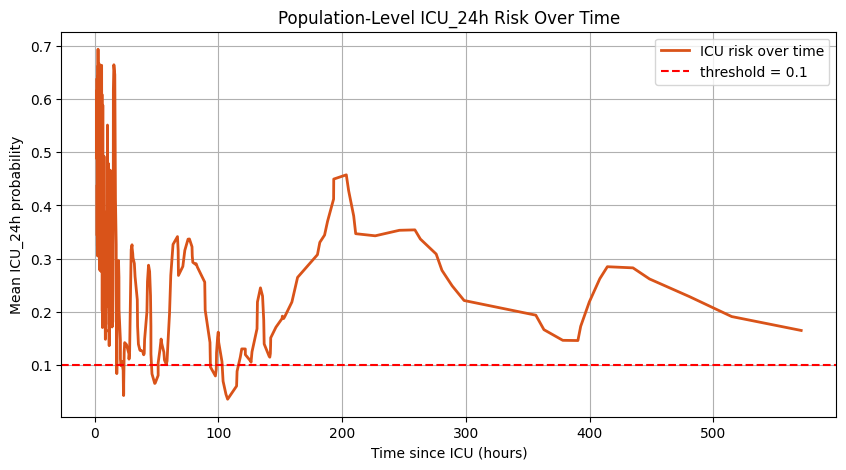

In [ ]:

# ----------------------------------------
# 7. plot
# ----------------------------------------
plt.figure(figsize=(10,5))

plt.plot(df_mean["time"], smooth_prob, linewidth=2,   color=(0.8500, 0.3250, 0.0980), label="ICU risk over time")

plt.axhline(0.1, color="red", linestyle="--", label="threshold = 0.1")

plt.xlabel("Time since ICU (hours)")
plt.ylabel("Mean ICU_24h probability")
plt.title("Population-Level ICU_24h Risk Over Time")

plt.legend()
plt.grid()
plt.show()

In [66]:
[c for c in test_df.columns if "time" in c.lower() or "hour" in c.lower() or "ecg" in c.lower()]

['general_ecg_time',
 'general_ecg_no_within_stay',
 'general_intime',
 'general_outtime',
 'general_mortality_hours',
 'general_hosp_dischtime',
 'general_icu_time_hours']

In [ ]:
def evaluate_thresholds(y_true, y_prob, thresholds=np.arange(0.00001, 0.01, 0.00001), cFP=1,
    cFN=1):
    
    results = []

    for thr in thresholds:

        y_pred = (y_prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn )   # recall
        specificity = tn / (tn + fp )

        precision = tp / (tp + fp)
        # Cost function
        cost = cFP * fp + cFN * fn

        results.append({
            "threshold": thr,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "False Positive": fp,
            "tp": tp,
            "False Negative": fn,
            "tn": tn,
            "cost": cost
        })

    return pd.DataFrame(results)

In [29]:
encoder.load_state_dict(torch.load("best_realmlp.pt"))
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [30]:
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(device)
        cat  = cat.to(device)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [ ]:
# 
all_results = []


mask = ~np.isnan(all_labels[:, 1])

y_true = all_labels[mask, i]
y_prob = all_preds[mask, i]

df_thr = evaluate_thresholds(y_true, y_prob, cFP=1, cFN=1)

print("\n")
print("="*60)
print('icu_24h')
print("="*60)

print(df_thr[[
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "False Positive",
    "False Negative"
]])
df_thr["label"] = 'icu_24h'

all_results.append(df_thr)

results_df = pd.concat(all_results, ignore_index=True)



mortality_1d
    threshold  sensitivity  specificity  precision  False Positive  \
0        0.05        0.450     0.975906   0.114650             139   
1        0.10        0.300     0.986653   0.134831              77   
2        0.15        0.225     0.990640   0.142857              54   
3        0.20        0.150     0.992026   0.115385              46   
4        0.25        0.150     0.993066   0.130435              40   
5        0.30        0.150     0.993240   0.133333              39   
6        0.35        0.150     0.993586   0.139535              37   
7        0.40        0.150     0.994106   0.150000              34   
8        0.45        0.150     0.994280   0.153846              33   
9        0.50        0.150     0.994453   0.157895              32   
10       0.55        0.150     0.995146   0.176471              28   
11       0.60        0.125     0.995493   0.161290              26   
12       0.65        0.125     0.996707   0.208333              19   
13   

In [49]:
icu_24h_results=results_df[results_df['label']=='icu_24h']
icu_24h_results.columns=['Threshold', 'Sensitivity', 'Specificity', 'Precision',
       'False Positive', 'True Positive', 'False Negative', 'True Negative', 'Cost Function', 'label']
icu_24h_results.drop(columns='label')

,Threshold,Sensitivity,Specificity,Precision,False Positive,True Positive,False Negative,True Negative,Cost Function
19,0.05,0.887538,0.666926,0.254023,1715,584,74,3434,1789
20,0.10,0.806991,0.810643,0.352590,975,531,127,4174,1102
21,0.15,0.744681,0.873179,0.428696,653,490,168,4496,821
22,0.20,0.676292,0.905030,0.476445,489,445,213,4660,702
23,0.25,0.615502,0.928918,0.525292,366,405,253,4783,619
24,0.30,0.562310,0.944261,0.563166,287,370,288,4862,575
25,0.35,0.504559,0.955914,0.593918,227,332,326,4922,553
26,0.40,0.466565,0.966595,0.640919,172,307,351,4977,523
27,0.45,0.419453,0.973976,0.673171,134,276,382,5015,516
28,0.50,0.373860,0.978442,0.689076,111,246,412,5038,523


In [38]:
lbl_itos_deterioration

['mortality_1d', 'icu_24h', 'cardiac_arrest', 'vasopressors']

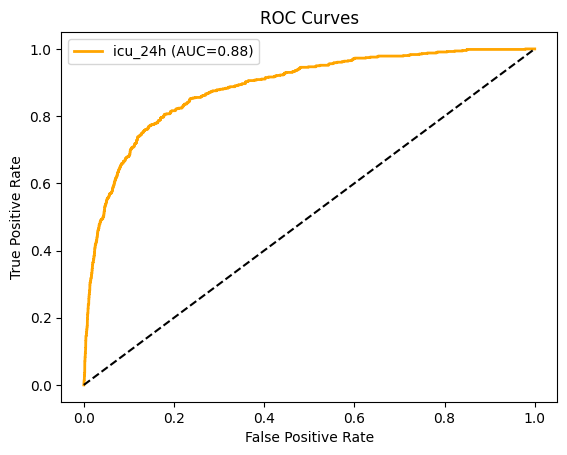

In [ ]:
plt.figure()

mask = ~np.isnan(all_labels[:, 1])

y_true = all_labels[mask, 1]
y_prob = all_preds[mask, 1]

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(
    fpr,
    tpr,
    color="orange",         
    linewidth=2,
    label=f"{'icu_24h'} (AUC={roc_auc:.2f})"
)

plt.plot([0, 1], [0, 1], "--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

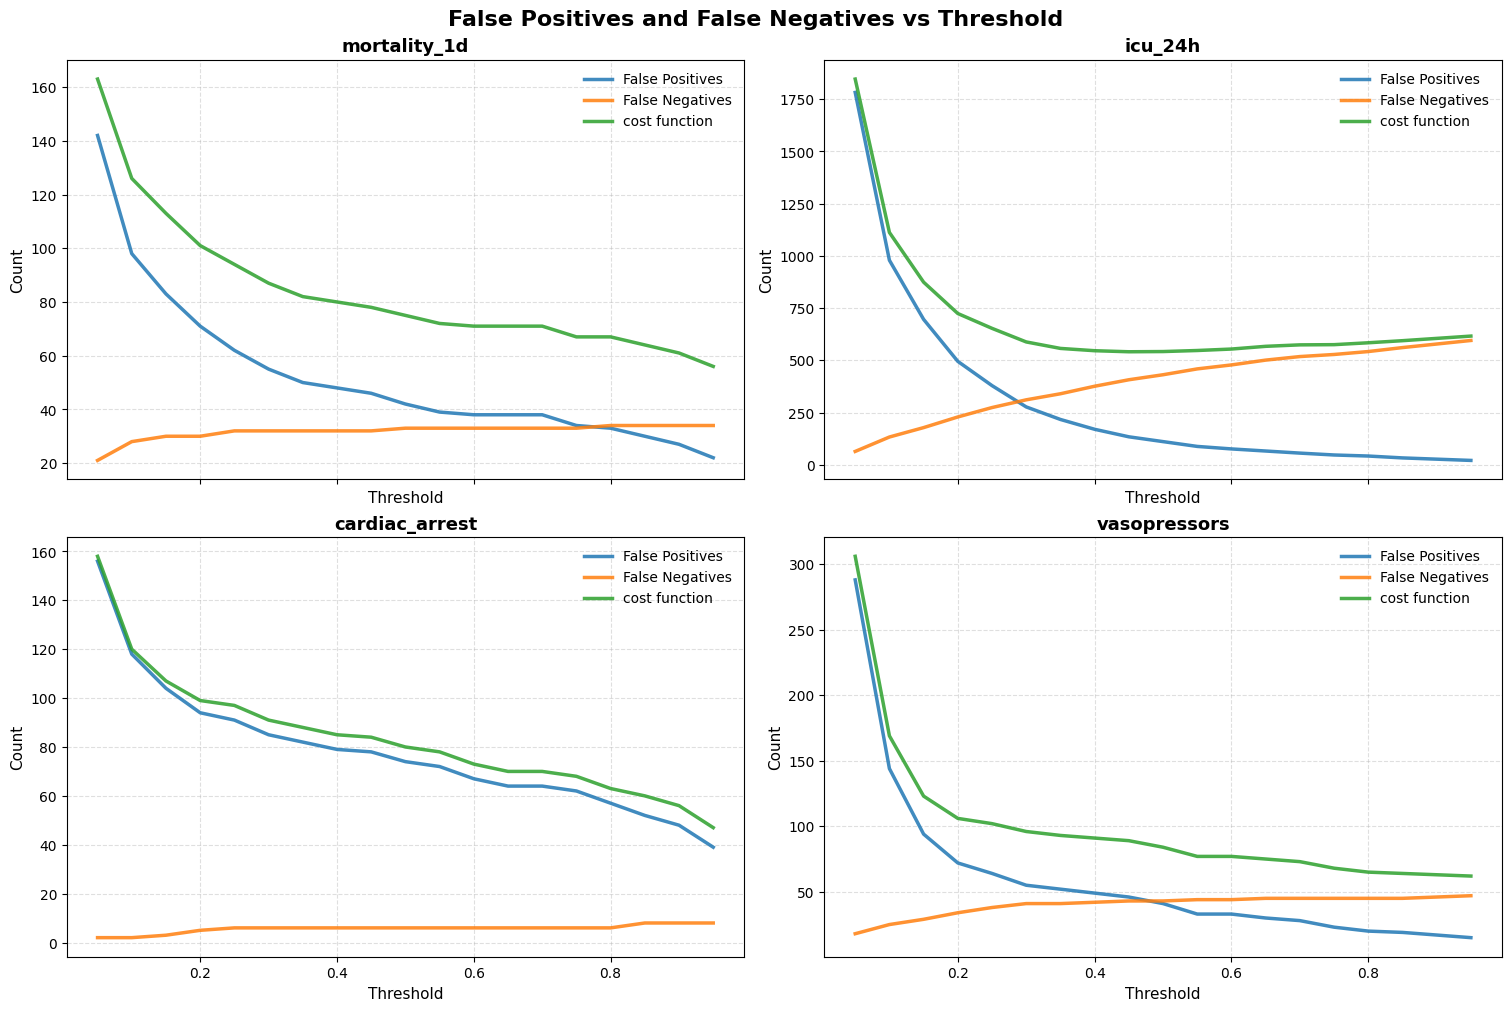

In [ ]:
labels = results_df["label"].unique()
best_row=[]
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10),
    sharex=True,
    constrained_layout=True
)

axes = axes.flatten()

for i, lbl in enumerate(labels):

    df = results_df[results_df["label"] == lbl]

    x = df["threshold"]
    fp = df["fp"]
    fn = df["fn"]
    cost_fct=df["cost"]
    best_row.append(df.loc[df["cost"].idxmin()])
    ax = axes[i]

    ax.plot(
        x, fp,
        label="False Positives",
        linewidth=2.5,
        alpha=0.85
    )

    ax.plot(
        x, fn,
        label="False Negatives",
        linewidth=2.5,
        alpha=0.85
    )
    ax.plot(
        x, cost_fct,
        label="cost function",
        linewidth=2.5,
        alpha=0.85
        )

    ax.set_title(lbl, fontsize=13, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.4)

    ax.legend(frameon=False)

# remove empty axes if fewer than 4 labels
for j in range(len(labels), 4):
    fig.delaxes(axes[j])

fig.suptitle("False Positives and False Negatives vs Threshold", fontsize=16, fontweight="bold")

plt.show()

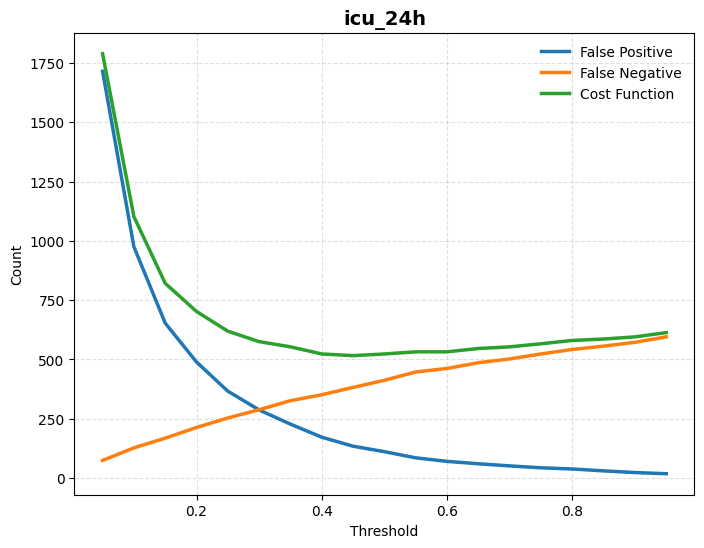

In [44]:
df = results_df[results_df["label"] == "icu_24h"]

x = df["threshold"]
fp = df["False Positive"]
fn = df["False Negative"]
cost_fct = df["cost"]

best_row = df.loc[df["cost"].idxmin()]

plt.figure(figsize=(8, 6))

plt.plot(x, fp, label="False Positive", linewidth=2.5)
plt.plot(x, fn, label="False Negative", linewidth=2.5)
plt.plot(x, cost_fct, label="Cost Function", linewidth=2.5)

plt.title("icu_24h", fontsize=14, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Count")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=False)

plt.show()

In [25]:
encoder.load_state_dict(torch.load('best_realmlp.pt'))
encoder.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for cont, cat, labels in test_loader:
        cont, cat = cont.to(device), cat.to(device)
        out = encoder(static=cont, static_cat=cat)
        logits = torch.sigmoid(out["static"])
        all_preds.append(logits.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

results = []
for i, col in enumerate(lbl_itos_deterioration):
    mask = ~np.isnan(all_labels[:, i])
    if mask.sum() > 0 and len(np.unique(all_labels[mask, i])) > 1:
        auroc = roc_auc_score(all_labels[mask, i], all_preds[mask, i])
        results.append({'target': col, 'auroc': auroc, 'n': mask.sum()})
        print(f"{col}: AUROC={auroc:.4f} (n={mask.sum()})")

results_df = pd.DataFrame(results)
print(f"\nMacro average AUROC: {results_df['auroc'].mean():.4f}")
results_df.to_csv('realmlp_results.csv', index=False)
print("Saved results: realmlp_results.csv")

mortality_1d: AUROC=0.9291 (n=6069)
icu_24h: AUROC=0.8835 (n=6051)
cardiac_arrest: AUROC=0.9445 (n=6080)
vasopressors: AUROC=0.8920 (n=6080)

Macro average AUROC: 0.9123
Saved results: realmlp_results.csv


In [26]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

In [27]:
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # ----------------------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels

In [28]:
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)


Running Monte Carlo Dropout...


In [29]:
results = []

for target_idx, target_name in enumerate(lbl_itos_deterioration):

    y_test = y_true[:, target_idx]
    y_pred = all_mean_preds[:, target_idx]
    uncertainty = all_uncertainties[:, target_idx]

    mask = ~np.isnan(y_test)

    y_test = y_test[mask]
    y_pred = y_pred[mask]
    uncertainty = uncertainty[mask]

    if len(np.unique(y_test)) < 2:
        continue

    auroc = roc_auc_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred)

    results.append({
        "target": target_name,
        "auroc": auroc,
        "auprc": auprc,
        "brier_score": brier,
        "mean_uncertainty": uncertainty.mean(),
        "test_n": len(y_test),
        "positive_rate": y_test.mean()
    })

results_df = pd.DataFrame(results)

results_df.to_csv("realmlp_mc_dropout_results.csv", index=False)

print("\n===== FINAL RESULTS =====")
print(results_df.to_string(index=False))


===== FINAL RESULTS =====
        target    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
  mortality_1d 0.933061 0.191730     0.005866          0.005048    6069       0.006591
       icu_24h 0.880518 0.572426     0.072813          0.038424    6051       0.120641
cardiac_arrest 0.948061 0.382205     0.004352          0.008184    6080       0.004934
  vasopressors 0.891086 0.110528     0.008329          0.007861    6080       0.008882


In [30]:
# ============================================================
# Evaluation with Entropy Uncertainty 
# ============================================================

encoder.eval()

all_probs = []
all_labels = []

epsilon = 1e-10

with torch.no_grad():

    for cont, cat, labels in test_loader:

        cont = cont.to(device)
        cat = cat.to(device)

        out = encoder(static=cont, static_cat=cat)
        logits = out["static"]

        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels.numpy())

# ------------------------------------------------------------
# Merge batches
# ------------------------------------------------------------

y_pred = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_labels, axis=0)

In [31]:
# Per-target evaluation
# ============================================================

results_list = []

for i, target_col in enumerate(target_cols):

    y_t = y_true[:, i]
    y_p = y_pred[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_t)

    y_t = y_t[mask]
    y_p = y_p[mask]

    # Skip empty tasks (safety)
    if len(y_t) == 0:
        continue

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    auroc = roc_auc_score(y_t, y_p)
    auprc = average_precision_score(y_t, y_p)
    brier = brier_score_loss(y_t, y_p)

    # --------------------------------------------------------
    # Entropy uncertainty
    # --------------------------------------------------------
    entropy = -(
        y_p * np.log(y_p + epsilon)
        + (1 - y_p) * np.log(1 - y_p + epsilon)
    )

    mean_uncertainty = entropy.mean()

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results_list.append({
        "target": target_col.replace("deterioration_", ""),
        "auroc": auroc,
        "auprc": auprc,
        "brier_score": brier,
        "mean_uncertainty": mean_uncertainty,
        "test_n": len(y_t),
        "positive_rate": y_t.mean()
    })


In [32]:
# Final table
# ============================================================

results = pd.DataFrame(results_list)

print("\n===== FINAL RESULTS =====")
print(results.to_string(index=False))

results.to_csv("Det_entropy_multimodal_results.csv", index=False)

print("\nSaved to:")
print("Det_entropy_multimodal_results.csv")


===== FINAL RESULTS =====
      target    auroc    auprc  brier_score  mean_uncertainty  test_n  positive_rate
mortality_1d 0.910491 0.055935     0.079368          0.034240    6069       0.006591
     icu_24h 0.871733 0.450934     0.110570          0.235291    6051       0.120641
     icu_24h 0.939540 0.066553     0.068711          0.023781    6080       0.004934
vasopressors 0.860487 0.048698     0.084053          0.051062    6080       0.008882

Saved to:
Det_entropy_multimodal_results.csv
